# Naive Bayes Classifier (ECOLI)

Ini adalah tahap modeling klasifikasi data ecoli menggunakan metode Naive Bayes dengan kondisi 
- Data ecoli yang belum di lakukan oversampling
- Data ecoli yang sudah di lakukan oversampling menggunakan SMOTE
- Data ecoli yang sudah di lakukan oversampling menggunakan ADASYN

kemudian di bandingkan apakah ada penambahan akurasi saat setelah data di lakukan oversampling

# Library yang digunakan

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Modeling Klasifikasi menggunakan Naive bayes pada data ecoli sebelum di oversampling

accuracy_score : 0.7205882352941176
Classification Report:
               precision    recall  f1-score   support

          cp       0.91      0.94      0.92        32
          im       0.59      0.77      0.67        13
         imS       0.00      0.00      0.00         1
         imU       0.00      0.00      0.00         4
          om       0.00      0.00      0.00         6
         omL       1.00      1.00      1.00         1
          pp       0.50      0.73      0.59        11

    accuracy                           0.72        68
   macro avg       0.43      0.49      0.45        68
weighted avg       0.64      0.72      0.67        68



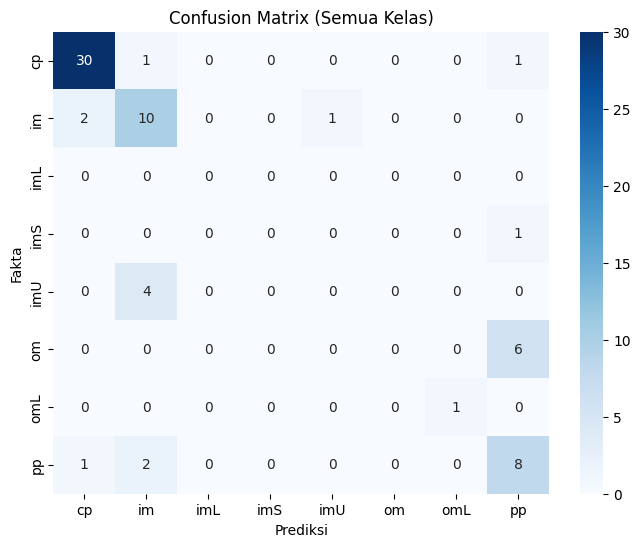

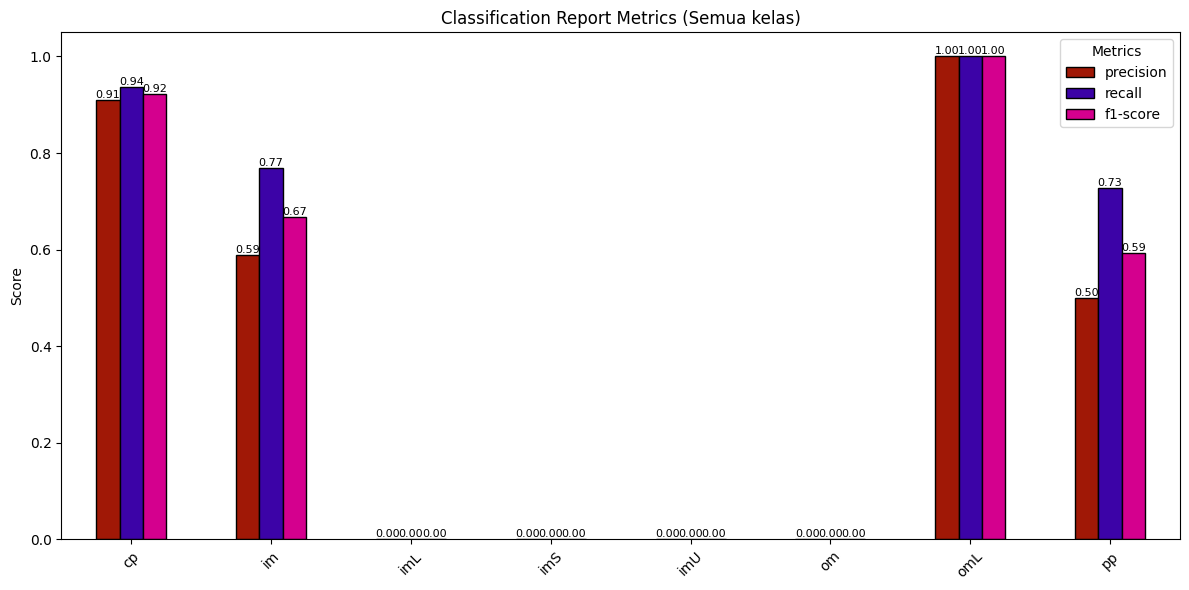

In [2]:
engine = create_engine("mysql+pymysql://root:@localhost/psd")
query = "SELECT mcg, gvh, lip, chg, aac, alm1, alm2, localization_class FROM ecoli"
df = pd.read_sql(query, engine)

X = df.drop(columns=["localization_class"])
y = df["localization_class"]

df

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

nb = GaussianNB()

nb.fit(X_train, y_train)

prediksi = nb.predict(X_test)

print(f"accuracy_score : {accuracy_score(y_test, prediksi)}")
print("Classification Report:\n", classification_report(y_test, prediksi, zero_division=0))

# confuison matrix

labels = np.unique(np.concatenate([y_train, y_test]))

cm = confusion_matrix(y_test, prediksi, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train, y_test]))

report = classification_report(
    y_test, prediksi, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], 
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


# Modeling Klasifikasi menggunakan Naive bayes pada data Ecoli setelah di Oversampling menggunakan SMOTE

accuracy_score : 0.8253275109170306
Classification Report:
               precision    recall  f1-score   support

          cp       0.97      0.97      0.97        32
          im       1.00      0.54      0.70        28
         imL       1.00      1.00      1.00        29
         imS       1.00      1.00      1.00        31
         imU       0.67      0.81      0.73        27
          om       1.00      0.28      0.43        29
         omL       0.95      1.00      0.97        19
          pp       0.56      1.00      0.72        34

    accuracy                           0.83       229
   macro avg       0.89      0.82      0.82       229
weighted avg       0.89      0.83      0.81       229



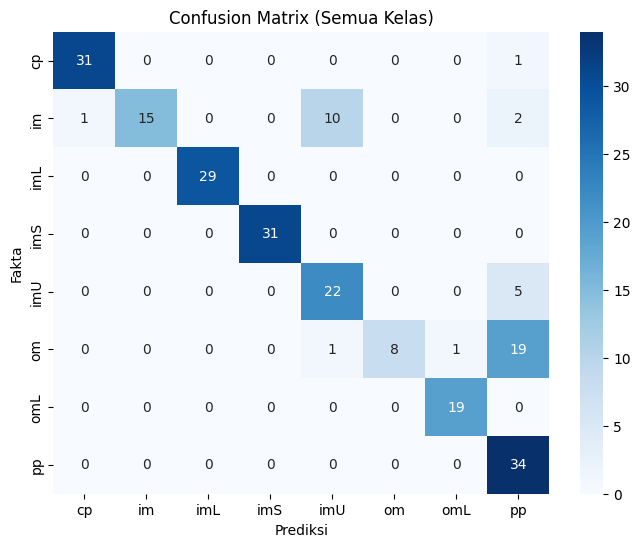

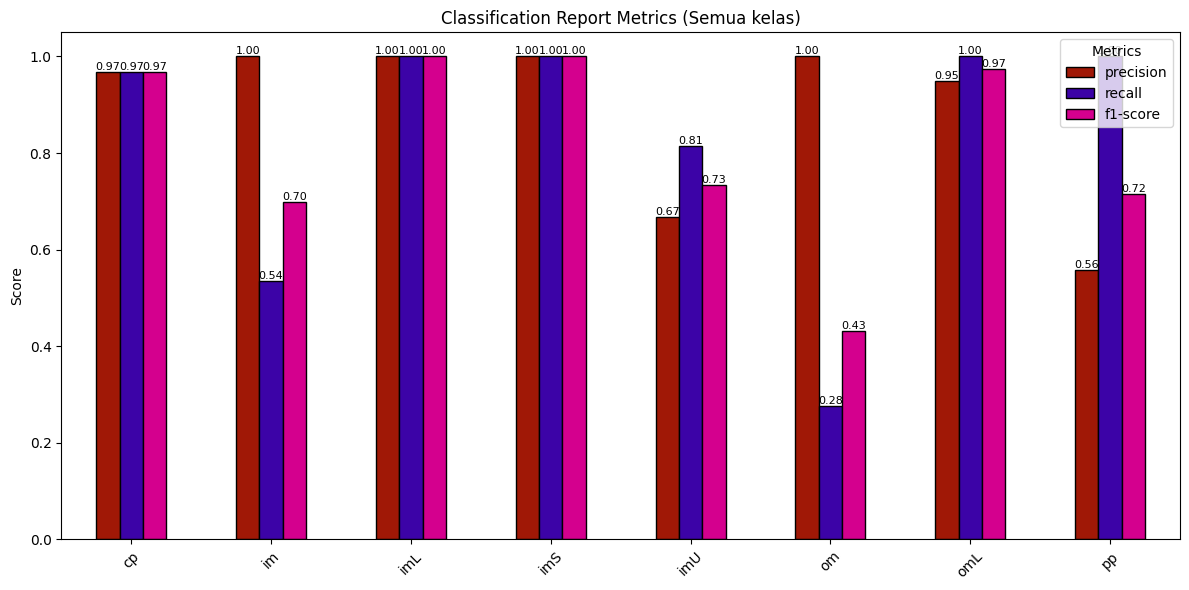

In [3]:
data_smote = pd.read_csv("../oversampling/hasil_oversampling_SMOTE.csv")
x_smote = data_smote.drop(columns=["class"])
y_smote = data_smote["class"]


X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42
)

nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)

prediksi_smote = nb.predict(X_test_smote)

print(f"accuracy_score : {accuracy_score(y_test_smote, prediksi_smote)}")
print("Classification Report:\n", classification_report(y_test_smote, prediksi_smote, zero_division=0))

# confuison matrix

labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))

cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))

report = classification_report(
    y_test_smote, prediksi_smote, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], # biru, oranye, hijau
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# Modeling Klasifikasi menggunakan Naive bayes pada data ecoli setelah di oversampling menggunakan ADASYN

accuracy_score : 0.8391304347826087
akurasi lengkap:
               precision    recall  f1-score   support

          cp       0.91      0.97      0.94        32
          im       0.94      0.56      0.70        27
         imL       1.00      1.00      1.00        28
         imS       0.94      1.00      0.97        31
         imU       0.76      0.84      0.80        31
          om       1.00      0.37      0.54        30
         omL       1.00      1.00      1.00        22
          pp       0.56      1.00      0.72        29

    accuracy                           0.84       230
   macro avg       0.89      0.84      0.83       230
weighted avg       0.88      0.84      0.83       230



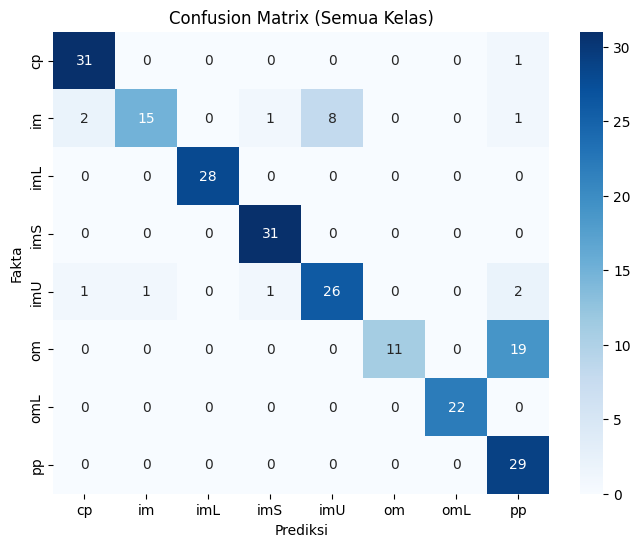

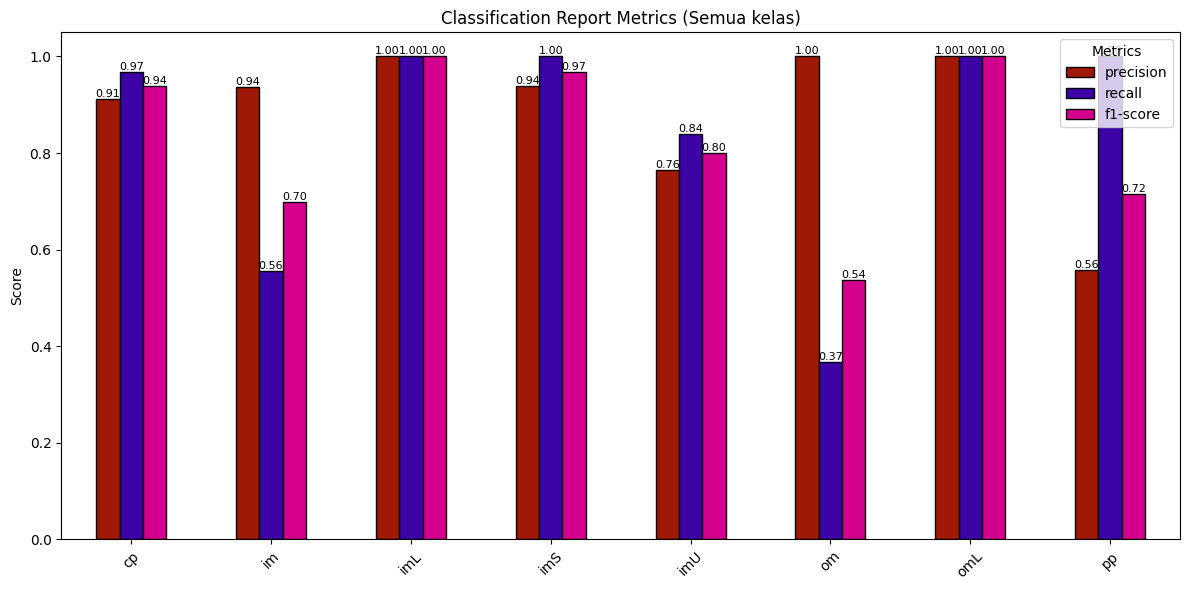

In [4]:
data_adasyn = pd.read_csv("../oversampling/hasil_oversampling_ADASYN.csv")
x_adasyn = data_adasyn.drop(columns=["class"])
y_adasyn = data_adasyn["class"]

X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    x_adasyn, y_adasyn, test_size=0.2, random_state=42
)

nb = GaussianNB()

nb.fit(X_train_adasyn, y_train_adasyn)

prediksi_adasyn = nb.predict(X_test_adasyn)

print(f"accuracy_score : {accuracy_score(y_test_adasyn, prediksi_adasyn)}")
print("akurasi lengkap:\n", classification_report(y_test_adasyn, prediksi_adasyn))

# confuison matrix

labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))

cm = confusion_matrix(y_test_adasyn, prediksi_adasyn, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))

report = classification_report(
    y_test_adasyn, prediksi_adasyn, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], # biru, oranye, hijau
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# Perbandingan akurasi antara data sebelum di oversampling dan sesudah

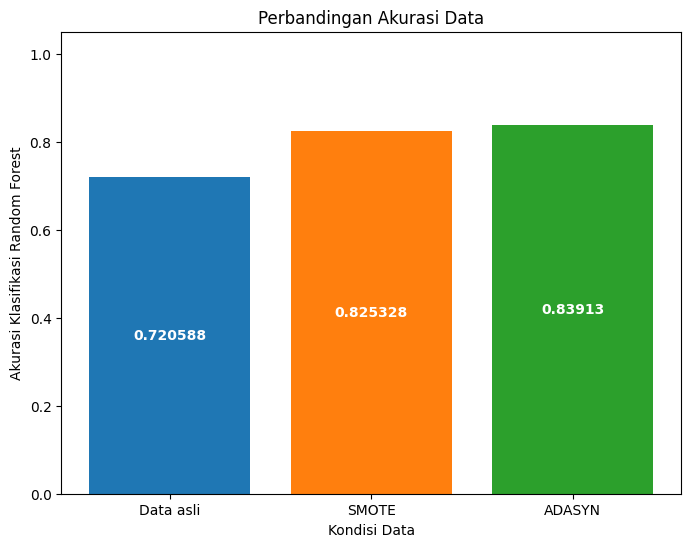

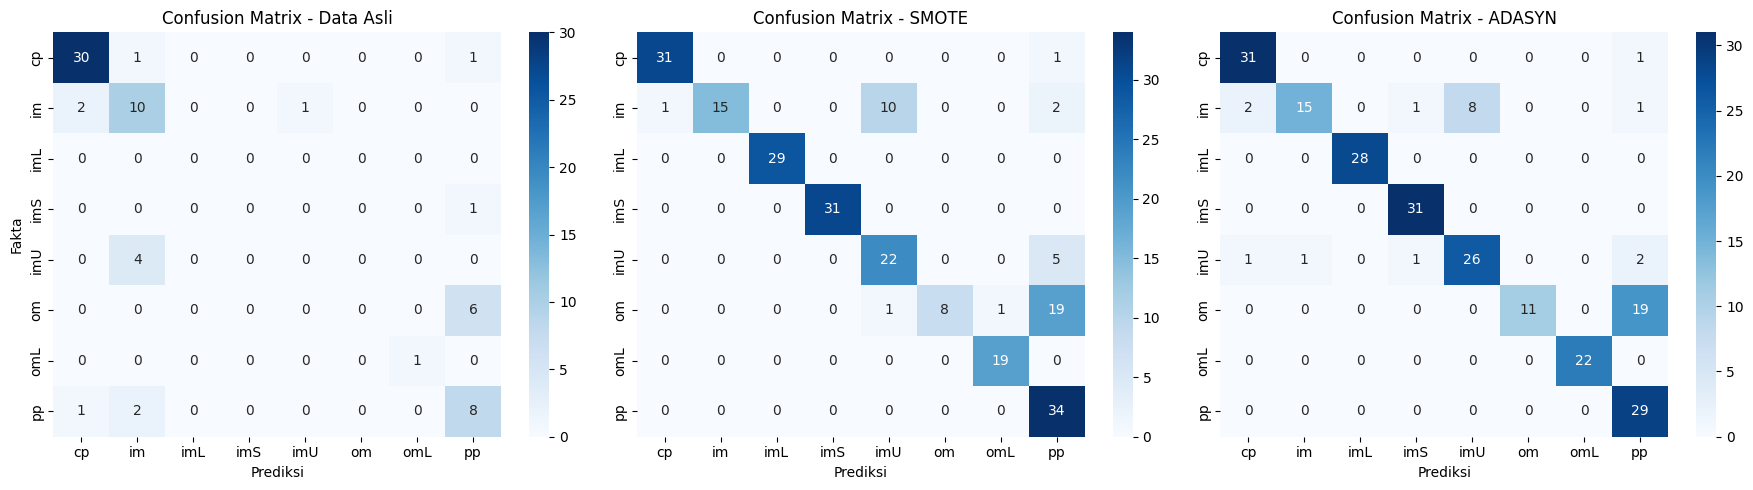

In [5]:
# data yang sebelum di overesampling 

akurasi = accuracy_score(y_test, prediksi)

# data yang sudah di oversampling menggunakan SMOTE

akurasi_smote = accuracy_score(y_test_smote, prediksi_smote)

# data yang sudah di oversampling menggunakan ADASYN

akurasi_adasyn = accuracy_score(y_test_adasyn, prediksi_adasyn)


label = ['Data asli', 'SMOTE', 'ADASYN']
temp = [akurasi, akurasi_smote, akurasi_adasyn]

fig, ax = plt.subplots(figsize=(8,6))

bc = ax.bar(label, temp, color=['#1f77b4','#ff7f0e','#2ca02c'])

ax.bar_label(bc, label_type='center', color='w', fontweight='bold')

ax.set(
    xlabel='Kondisi Data',
    ylabel='Akurasi Klasifikasi Random Forest',
    title='Perbandingan Akurasi Data'
)

ax.set_ylim(0, 1.05)

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Data asli
labels = np.unique(np.concatenate([y_train, y_test]))
cm = confusion_matrix(y_test, prediksi, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix - Data Asli")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Fakta")

# Data SMOTE
labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))
cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion Matrix - SMOTE")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("")

# Data ADASYN
labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))
cm = confusion_matrix(y_test_adasyn, prediksi_adasyn, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[2])
axes[2].set_title("Confusion Matrix - ADASYN")
axes[2].set_xlabel("Prediksi")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

Berdasarkan grafik perbandingan akurasi klasifikasi Naive Bayes, terlihat bahwa pada data asli akurasi hanya mencapai 72,0%, namun setelah dilakukan oversampling dengan SMOTE akurasi meningkat menjadi 82,5%, dan dengan ADASYN akurasi meningkat lebih tinggi lagi hingga 85,7%. Hal ini menunjukkan bahwa penggunaan teknik oversampling, khususnya ADASYN, mampu memberikan hasil yang lebih baik dibandingkan data asli, sehingga model dapat mengatasi masalah ketidakseimbangan kelas dengan lebih efektif.